# Generate Synthetic Data with TVAE
This notebook synthesizes a single-row-per-subject dataset using SDV's TVAESynthesizer.

It follows the same path-configuration style as the empirical analysis notebook:
- Centralized directory constants at the top
- Explicit input/output file paths
- Reusable tuning constants for synthesis and plotting

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sdv.metadata import Metadata
from sdv.single_table import TVAESynthesizer

# Centralized paths for reproducible I/O
DATA_DIR = Path("/fp/projects01/ec201/userdata/ec-edvardsg/reconsider_brain_age")
OUTPUT_DIR = Path("/fp/projects01/ec201/userdata/ec-edvardsg/reconsider_brain_age_synthetic")
FIGURES_DIR = Path("figures")

INPUT_CSV = DATA_DIR / "brain_age_data_processed.csv"
FEATURE_SET_FILE = DATA_DIR / "features.json"
OUTPUT_CSV = OUTPUT_DIR / "synthetic_data.csv"

# Synthesis and plotting settings
N_SYNTHETIC_ROWS = 20000
N_EPOCHS = 5000
BATCH_SIZE = 5000
N_LINE_SAMPLES = 1000
LINE_HALF_WIDTH_YEARS = 5

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

In [2]:
df = pd.read_csv(INPUT_CSV, low_memory=False)

with open(FEATURE_SET_FILE, "r") as f:
    feature_sets = json.load(f)

features = feature_sets["features_all"]
len(features)

121

In [3]:
# Sort by participant and age to preserve temporal ordering before row selection
df = df.sort_values(by=["rid", "age"]).reset_index(drop=True)

In [4]:
cat_columns = ["sex_female", "Dx", "groupTAU", "dataset"]

mri_intercept_columns = [f"{col}_intercept_z" for col in features]
mri_slope_columns = [f"{col}_slope_z" for col in features]
features_corr_z = [f"{col}_site_corr_z" for col in features]

mri_columns = mri_intercept_columns + mri_slope_columns + features_corr_z + features
cont_columns = ["age", "age_mean", "bw", "esttau", "EstimatedTotalIntraCranialVol_z"] + mri_columns

In [5]:
# Keep only identifier, categorical, and continuous columns used for synthesis
columns_to_keep = ["rid"] + cat_columns + cont_columns

missing_cols = [col for col in columns_to_keep if col not in df.columns]
if missing_cols:
    raise KeyError(f"Missing expected columns: {missing_cols[:10]}")

df = df[columns_to_keep]

In [6]:
# Keep rows complete for model-critical columns, while allowing missing outcome-style fields
optional_missing = ["bw", "groupTAU", "esttau"]
required_columns = [col for col in df.columns if col not in optional_missing]
df = df.dropna(subset=required_columns).reset_index(drop=True)

In [7]:
# Clip the top and bottom 1% of all slope values
slope_columns = [col for col in df.columns if col.endswith("_slope_z")]
for col in slope_columns:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df.loc[df[col] < lower_bound, col] = lower_bound
    df.loc[df[col] > upper_bound, col] = upper_bound

<Axes: >

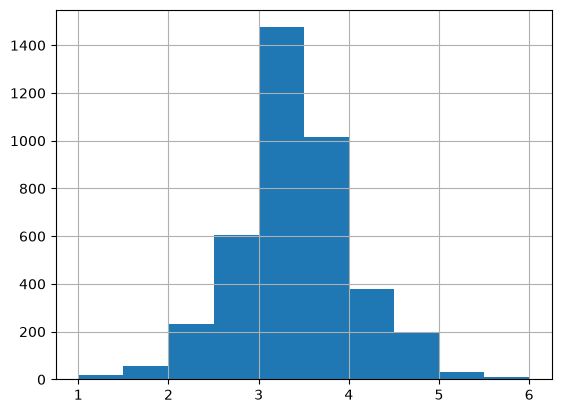

In [8]:
# Divide bw values over 10 by 1000
df.loc[df["bw"] > 10, "bw"] = df.loc[df["bw"] > 10, "bw"] / 1000

# Clip bw values between 1 and 6
df["bw"] = df["bw"].clip(1, 6)

# Plot a histogram of the bw
df["bw"].hist()

In [9]:
# Use one row per participant for single-table synthesis
df_single_instance = df.groupby("rid", as_index=False).first()
df_single_instance.shape

(5211, 494)

In [10]:
df_single_instance

,rid,sex_female,Dx,groupTAU,dataset,age,age_mean,bw,esttau,EstimatedTotalIntraCranialVol_z,...,Amygdala,CSF,Accumbens-area,VentralDC,vessel,choroid-plexus,SubCortGrayVol,TotalGrayVol,SupraTentorialVol,EstimatedTotalIntraCranialVol
0,0,1.0,1.0,None,adni,74.00,74.875,NaN,NaN,-0.398028,...,2252.7,1034.4,794.1,7188.4,322.4,3059.0,47501.0,564799.465874,951419.0,1.479759e+06
1,1,0.0,1.0,None,adni,69.40,69.950,NaN,NaN,-0.257384,...,1931.7,1344.5,581.7,7157.9,176.4,2886.0,46698.0,529448.174022,961940.0,1.501860e+06
2,2,1.0,0.0,None,adni,77.00,78.400,NaN,NaN,0.444168,...,2831.9,1228.9,737.0,6232.4,301.7,3760.8,49217.0,599606.427959,1020557.0,1.612103e+06
3,3,1.0,1.0,None,adni,75.00,78.180,NaN,NaN,-0.728514,...,1938.1,1658.6,502.3,6411.5,158.2,3502.0,47103.0,490214.145861,840441.0,1.427826e+06
4,4,0.0,1.0,None,adni,73.00,73.725,NaN,NaN,1.250809,...,2326.4,1708.7,909.5,8012.4,223.3,3808.6,52751.0,592464.612556,1086140.0,1.738860e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5206,49145,1.0,0.0,None,ukb_sc,55.95,57.015,3.86,NaN,-0.734915,...,3009.7,1155.0,974.5,7866.5,78.2,1021.3,55121.0,618833.000000,993499.0,1.426820e+06
5207,49173,1.0,0.0,None,ukb_sc,51.31,52.630,NaN,NaN,-0.433913,...,3161.3,929.5,836.9,7850.5,37.6,959.5,50304.0,630373.000000,979671.0,1.474120e+06
5208,49184,1.0,0.0,None,ukb_sc,68.36,69.465,3.18,NaN,-0.797406,...,3021.3,831.6,745.8,6640.7,145.8,723.2,50612.0,601252.000000,950255.0,1.417000e+06
5209,49202,1.0,0.0,None,ukb_sc,54.53,55.640,NaN,NaN,-0.381158,...,3354.8,939.3,858.9,7351.1,71.1,721.1,53483.0,671302.000000,1044940.0,1.482410e+06


In [11]:
# Show available datasets after filtering
sorted(pd.unique(df["dataset"]))

['adni', 'dlbs', 'habs', 'preventad', 'uio', 'ukb', 'ukb_sc']

In [12]:
metadata = Metadata.detect_from_dataframe(df_single_instance)

for col in cat_columns:
    metadata.update_column(column_name=col, sdtype="categorical")

for col in cont_columns:
    metadata.update_column(column_name=col, sdtype="numerical")

metadata.update_column(column_name="rid", sdtype="id")

synthesizer = TVAESynthesizer(
    metadata,
    epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=True,
)

synthesizer.fit(df_single_instance)

/projects/ec201/userdata/ec-edvardsg/conda_envs/ctgan/lib/python3.11/site-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Loss: +99.99: 100%|██████████| 5000/5000 [28:44<00:00,  2.90it/s]


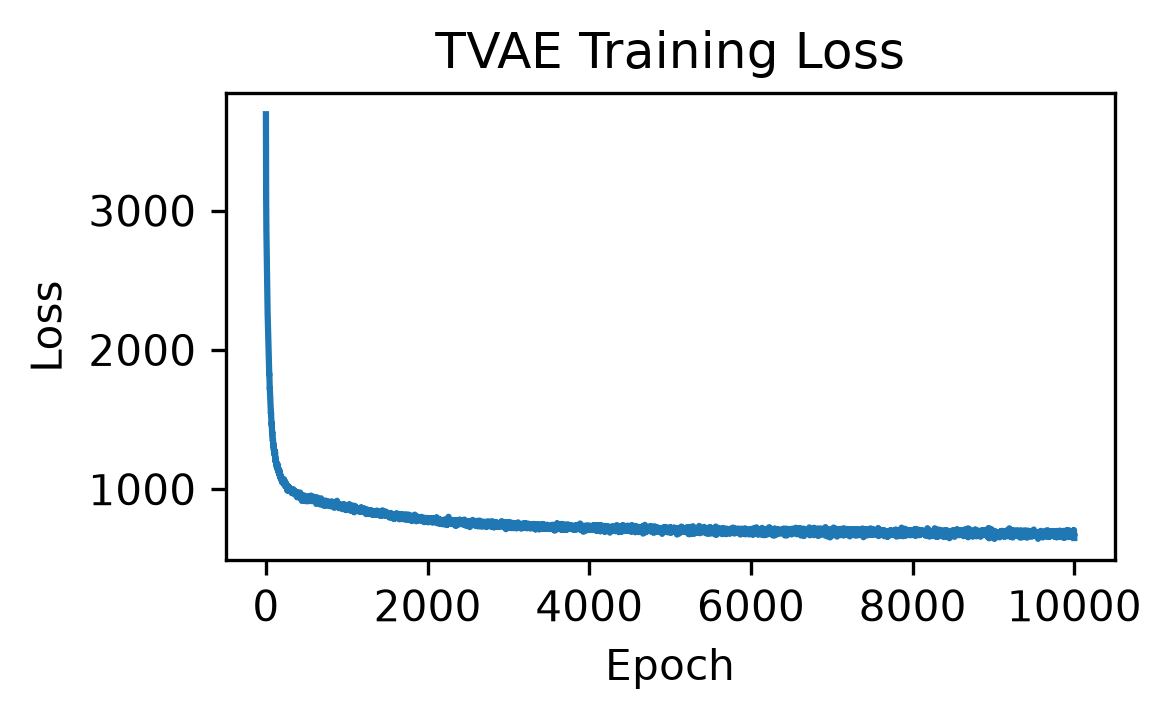

In [13]:
loss = synthesizer.get_loss_values()

fig, ax = plt.subplots(figsize=(4, 2.5), dpi=300)
ax.plot(loss["Loss"])
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("TVAE Training Loss")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "tvae_training_loss.svg", bbox_inches="tight")
plt.show()

In [14]:
synthetic = synthesizer.sample(num_rows=N_SYNTHETIC_ROWS)
synthetic.shape

(20000, 494)

In [15]:
synthetic.head()

,rid,sex_female,Dx,groupTAU,dataset,age,age_mean,bw,esttau,EstimatedTotalIntraCranialVol_z,...,Amygdala,CSF,Accumbens-area,VentralDC,vessel,choroid-plexus,SubCortGrayVol,TotalGrayVol,SupraTentorialVol,EstimatedTotalIntraCranialVol
0,1482446,1.0,0.0,TAU_neg,preventad,58.643809,60.880069,NaN,1.05663,-1.467451,...,3275.146201,937.12,746.215042,7332.502188,106.304564,2180.845375,52368.7,539703.781995,883035.021297,1.393468e+06
1,9440055,1.0,0.0,NaN,preventad,74.724439,74.185710,NaN,NaN,-1.460239,...,2826.140947,701.23,1102.655665,7506.713668,249.865055,2188.784102,55239.0,585749.828704,920084.403999,1.441485e+06
2,13038129,1.0,0.0,NaN,adni,70.741260,80.323721,NaN,NaN,-1.723770,...,3036.903568,928.45,831.749116,5970.788398,174.492186,2276.587142,51324.0,607191.421064,873981.792811,1.466589e+06
3,11688779,0.0,1.0,NaN,adni,74.589303,80.615617,3.390777,NaN,-0.521147,...,2061.211628,1259.86,887.163011,6684.483391,129.777529,2702.701273,51245.9,571990.923936,868415.827945,1.379997e+06
4,783034,0.0,0.0,NaN,dlbs,67.234461,61.871779,3.378798,NaN,0.139312,...,3724.239143,1184.39,1294.087010,8593.127287,285.162523,2516.506976,65856.3,639662.845116,949228.299800,1.498492e+06


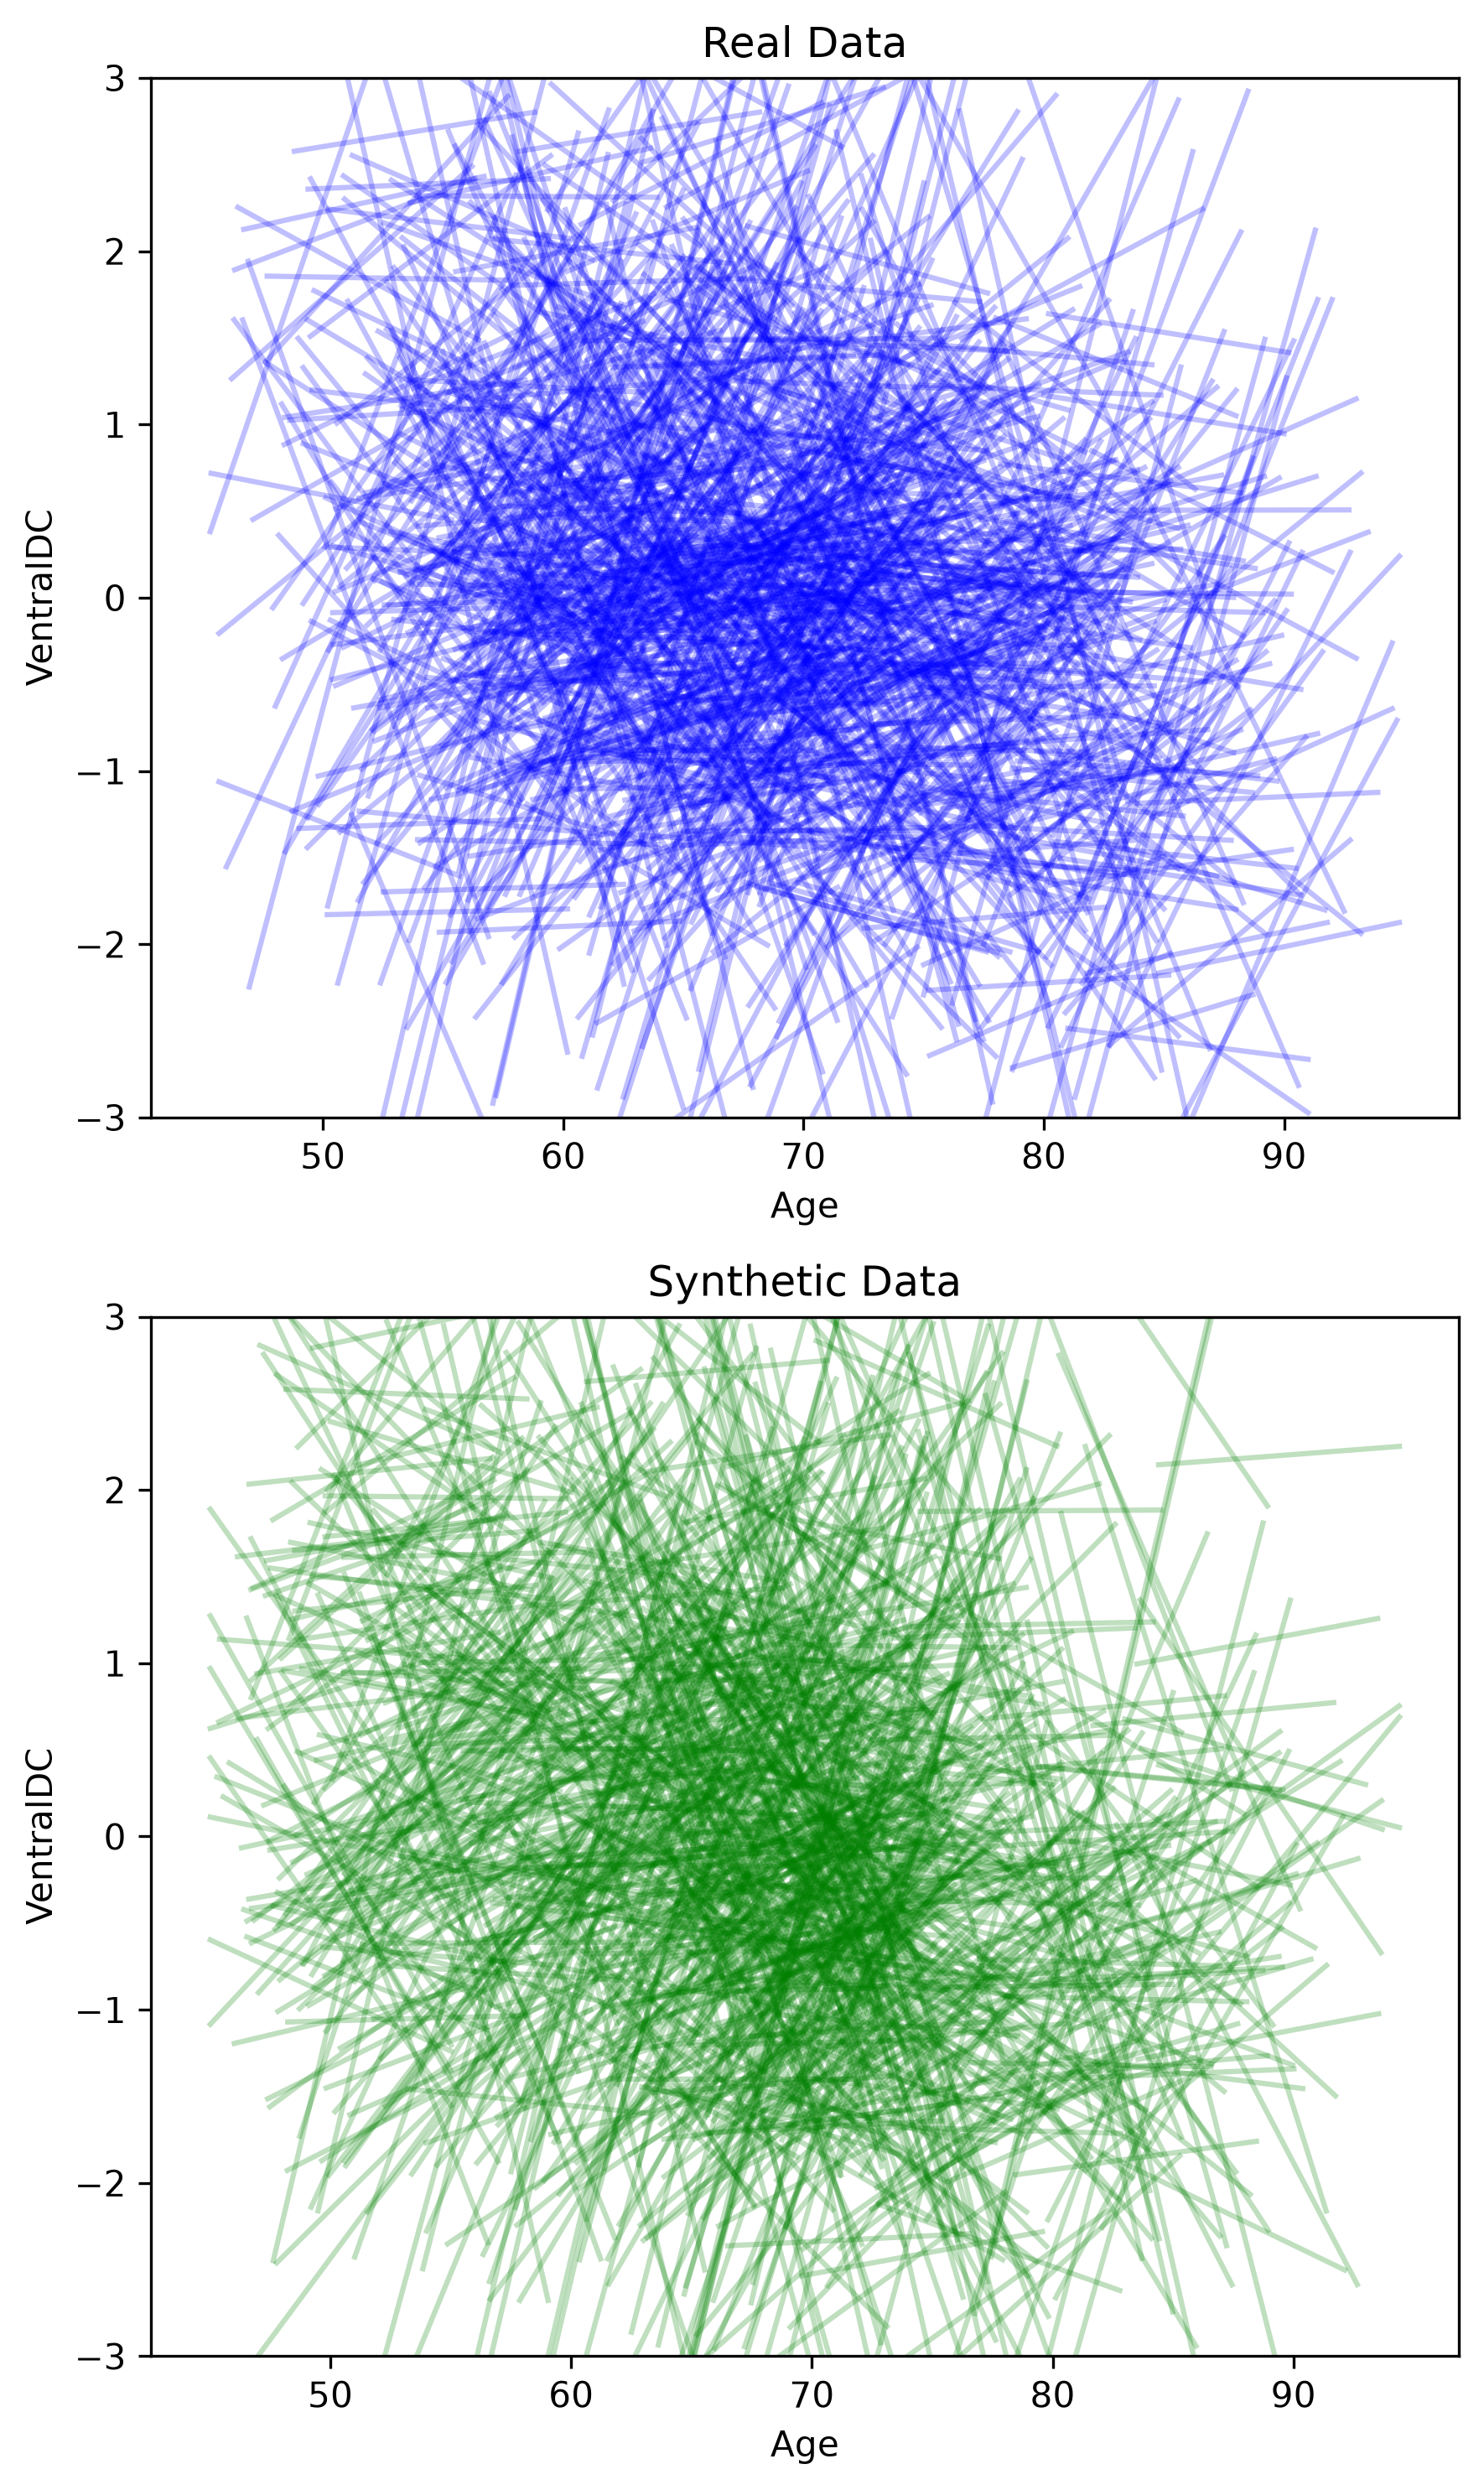

In [16]:
# Plot intercept/slope implied trajectories for a representative feature
fig, axs = plt.subplots(2, 1, figsize=(6, 10), dpi=300)

for row in df.sample(n=min(N_LINE_SAMPLES, len(df))).itertuples():
    age = row.age
    intercept = row.VentralDC_intercept_z
    slope = row.VentralDC_slope_z
    axs[0].plot(
        [age - LINE_HALF_WIDTH_YEARS, age + LINE_HALF_WIDTH_YEARS],
        [intercept - LINE_HALF_WIDTH_YEARS * slope, intercept + LINE_HALF_WIDTH_YEARS * slope],
        color="blue",
        alpha=0.25,
    )

for row in synthetic.sample(n=min(N_LINE_SAMPLES, len(synthetic))).itertuples():
    age = row.age
    intercept = row.VentralDC_intercept_z
    slope = row.VentralDC_slope_z
    axs[1].plot(
        [age - LINE_HALF_WIDTH_YEARS, age + LINE_HALF_WIDTH_YEARS],
        [intercept - LINE_HALF_WIDTH_YEARS * slope, intercept + LINE_HALF_WIDTH_YEARS * slope],
        color="green",
        alpha=0.25,
    )

axs[0].set_xlabel("Age")
axs[0].set_ylabel("VentralDC")
axs[1].set_xlabel("Age")
axs[1].set_ylabel("VentralDC")

axs[0].set_title("Real Data")
axs[1].set_title("Synthetic Data")

axs[0].set_ylim([-3, 3])
axs[1].set_ylim([-3, 3])
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ventraldc_trajectory_comparison.svg", bbox_inches="tight")
plt.show()

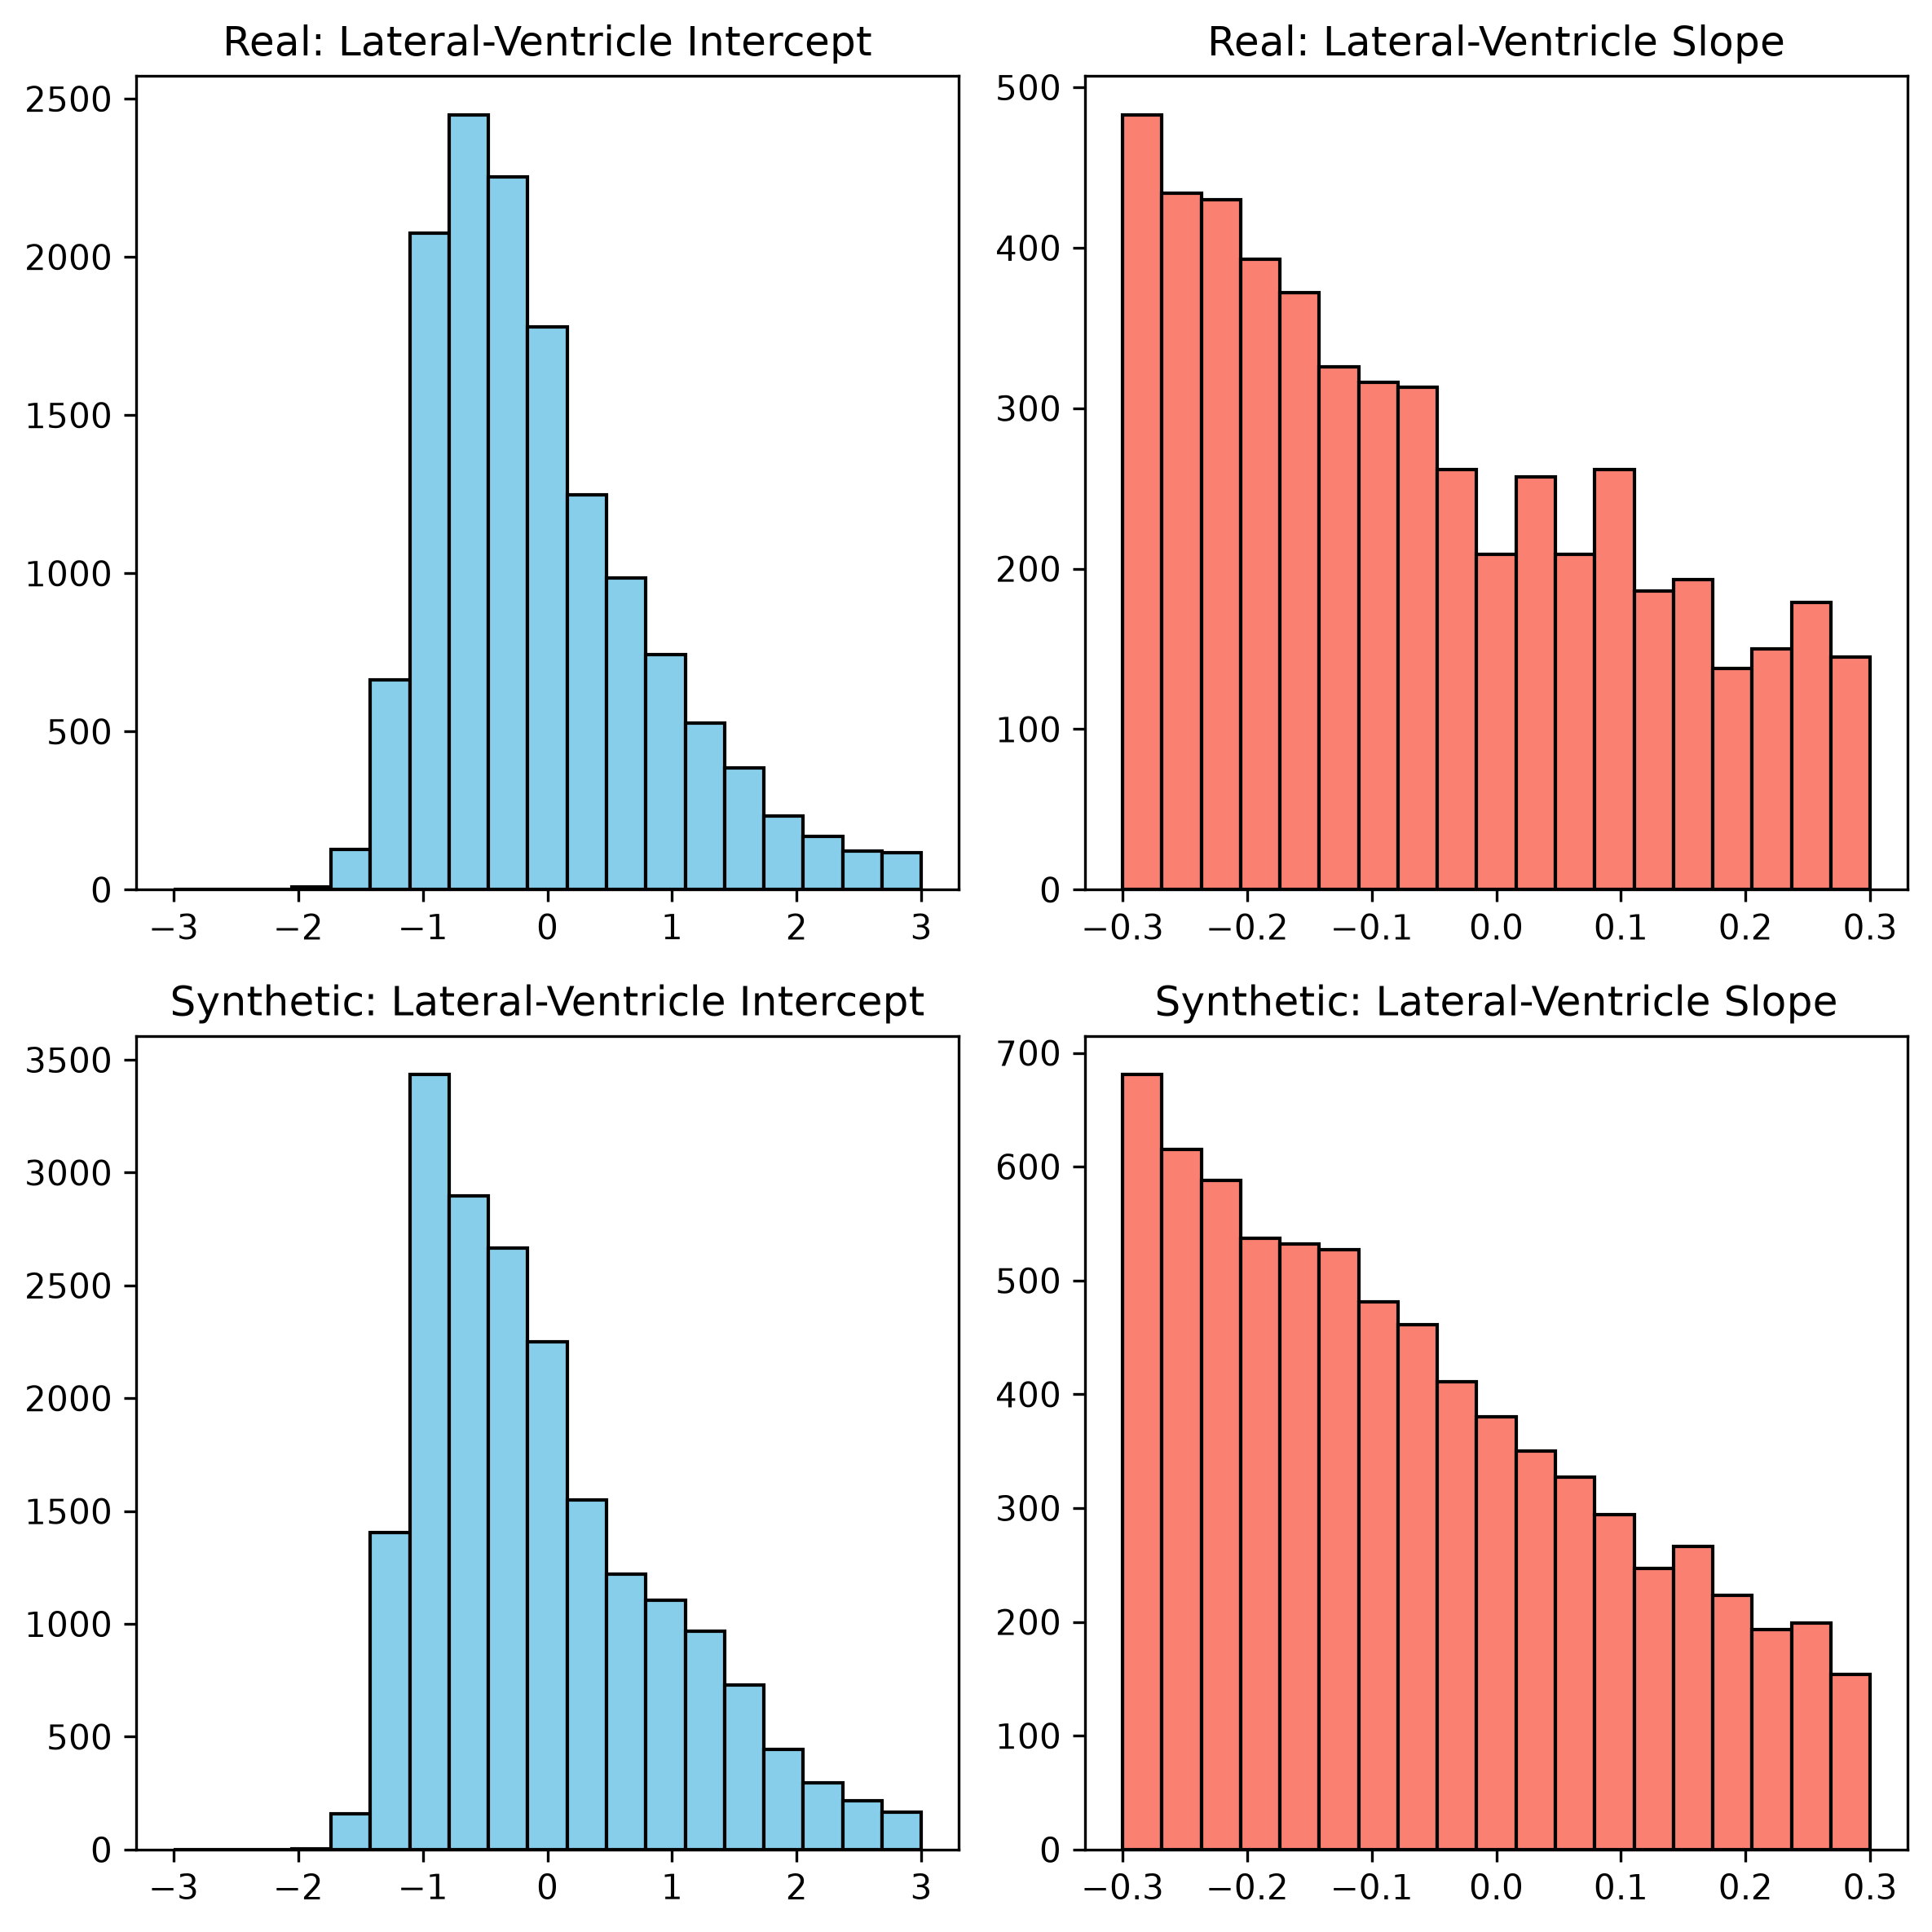

In [17]:
# Plot intercept and slope distributions for real vs synthetic data
feature = "Lateral-Ventricle"

bins_intercept = np.linspace(-3, 3, 20)
bins_slope = np.linspace(-0.3, 0.3, 20)

fig, axs = plt.subplots(2, 2, figsize=(8, 8), dpi=300)

intercept_coeffs = df[f"{feature}_intercept_z"]
slope_coeffs = df[f"{feature}_slope_z"]
axs[0, 0].hist(intercept_coeffs, bins=bins_intercept, color="skyblue", edgecolor="black")
axs[0, 0].set_title(f"Real: {feature} Intercept")
axs[0, 1].hist(slope_coeffs, bins=bins_slope, color="salmon", edgecolor="black")
axs[0, 1].set_title(f"Real: {feature} Slope")

intercept_coeffs_syn = synthetic[f"{feature}_intercept_z"]
slope_coeffs_syn = synthetic[f"{feature}_slope_z"]
axs[1, 0].hist(intercept_coeffs_syn, bins=bins_intercept, color="skyblue", edgecolor="black")
axs[1, 0].set_title(f"Synthetic: {feature} Intercept")
axs[1, 1].hist(slope_coeffs_syn, bins=bins_slope, color="salmon", edgecolor="black")
axs[1, 1].set_title(f"Synthetic: {feature} Slope")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "lateral_ventricle_distribution_comparison.svg", bbox_inches="tight")
plt.show()

In [ ]:
# Assign folds 0..4 for downstream cross-validation workflows
synthetic["test_fold"] = (synthetic.index % 5)
synthetic["test_fold"] = synthetic["test_fold"].astype(int)
synthetic["test_fold"].value_counts().sort_index()

/tmp/ipykernel_2071325/2858669368.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  synthetic["test_fold"] = (synthetic.index % 5) + 1


test_fold
1    4000
2    4000
3    4000
4    4000
5    4000
Name: count, dtype: int64

In [19]:
# Save synthetic dataset
synthetic.to_csv(OUTPUT_CSV, index=False)
print(f"Saved synthetic data to: {OUTPUT_CSV}")

Saved synthetic data to: /fp/projects01/ec201/userdata/ec-edvardsg/reconsider_brain_age_synthetic/synthetic_data.csv
